In [3]:
# DOI analysis
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import pandas as pd
from matplotlib import patches
import random
from scipy.optimize import curve_fit
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
indices = {
      0 : (4,7-7),
      1 : (4,7-6),
      2 : (7,7-5),
      3 : (5,7-7),
      4 : (5,7-4),
      5 : (5,7-5),
      6 : (4,7-4),
      7 : (7,7-7),
      8 : (6,7-6),
      9 : (7,7-4),
      10 : (5,7-6),
      11 : (6,7-4),
      12 : (4,7-5),
      13 : (6,7-5),
      14 : (6,7-7),
      15 : (7,7-6),
      16 : (3,7-7),
      17 : (3,7-6),
      18 : (2,7-7),
      19 : (2,7-6),
      20 : (0,7-7),
      21 : (1,7-7),
      22 : (0,7-6),
      23 : (1,7-6),
      24 : (3,7-5),
      25 : (1,7-5),
      26 : (2,7-5),
      27 : (4,7-3),
      28 : (0,7-5),
      29 : (3,7-4),
      30 : (0,7-4),
      31 : (1,7-4),
      32 : (2,7-4),
      33 : (3,7-3),
      34 : (2,7-3),
      35 : (0,7-3),
      36 : (1,7-3),
      37 : (0,7-2),
      38 : (5,7-3),
      39 : (1,7-2),
      40 : (2,7-2),
      41 : (3,7-2),
      42 : (1,7-1),
      43 : (0,7-1),
      44 : (0,7-0),
      45 : (3,7-1),
      46 : (1,7-0),
      47 : (2,7-1),
      48 : (3,7-0),
      49 : (2,7-0),
      50 : (6,7-2),
      51 : (6,7-1),
      52 : (7,7-1),
      53 : (4,7-1),
      54 : (5,7-1),
      55 : (6,7-0),
      56 : (7,7-0),
      57 : (7,7-2),
      58 : (7,7-3),
      59 : (4,7-2),
      60 : (5,7-0),
      61 : (5,7-2),
      62 : (6,7-3),
      63 : (4,7-0),
      64:(3+8,7),
      65:(3+8,6),
      66:(2+8,4),
      67:(2+8,6),
      68:(3+8,4),
      69:(1+8,7),
      70:(1+8,5),
      71:(0+8,7),
      72:(1+8,6),
      73:(3+8,3),
      74:(2+8,7),
      75:(2+8,3),
      76:(3+8,5),
      77:(0+8,5),
      78:(2+8,5),
      79:(0+8,6),
      80:(4+8,7),
      81:(6+8,7),
      82:(5+8,7),
      83:(7+8,7),
      84:(5+8,6),
      85:(4+8,6),
      86:(6+8,6),
      87:(7+8,6),
      88:(4+8,5),
      89:(6+8,5),
      90:(5+8,5),
      91:(1+8,4),
      92:(7+8,5),
      93:(7+8,4),
      94:(6+8,4),
      95:(4+8,4),
      96:(5+8,4),
      97:(5+8,3),
      98:(6+8,3),
      99:(4+8,3),
      100:(7+8,3),
      101:(7+8,2),
      102:(0+8,4),
      103:(6+8,2),
      104:(7+8,1),
      105:(5+8,2),
      106:(6+8,1),
      107:(4+8,2),
      108:(7+8,0),
      109:(5+8,1),
      110:(6+8,0),
      111:(4+8,1),
      112:(5+8,0),
      113:(4+8,0),
      114:(0+8,2),
      115:(2+8,1),
      116:(0+8,1),
      117:(3+8,1),
      118:(1+8,1),
      119:(1+8,0),
      120:(0+8,0),
      121:(1+8,2),
      122:(1+8,3),
      123:(3+8,2),
      124:(2+8,0),
      125:(2+8,2),
      126:(0+8,3),
      127:(3+8,0)}

# Hardcode indices
crystal_indices = [72, 69, 67, 74, 65, 64, 85, 80]
crystal_indices_down = [86, 87, 89, 92, 94, 93,98, 100]
crystal_indices_left = [106, 110, 109, 112, 111, 113, 117, 127]
crystal_indices_up = [118, 116, 121, 114, 122, 126, 91, 102]
#unpolished_indices = [x for x in range(64, 128) if x not in rough5micron_indices and x not in rough14micron_indices and x not in rough28micron_indices]
#indices_list = [unpolished_indices, rough5micron_indices, rough14micron_indices, rough28micron_indices]
# Define valid index pairs in DOI crystals
index_pairs = []
for i in range(64, 128):
    coord = indices[i]
    # find the dictionary key with value (coord[0], 7-coord[1])
    other = next(k for k, v in indices.items() if v == (coord[0], 7-coord[1]))
    index_pairs.append((i, other))

print(index_pairs)

def get_compliment(index):
    # Get the second index of the pair with the given index as the first index
    return next(pair[1] for pair in index_pairs if pair[0] == index)


def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeak(hist, bins):
    photopeak = 0
    for i in range(1, len(hist)-4):
        #if hist[-1*i] > hist[-1*(i+1)] and hist[-1*i] > hist[-1*(i+2)] and hist[-1*i] >= 0.5 * np.max(hist):
        if hist[-1*i] >= 0.5 * np.max(hist):
            photopeak = len(hist)-1*i
            break
    fit_p = [0,1,1]
    fit_x = list(bins[photopeak-5:photopeak+10])
    fit_y = list(hist[photopeak-5:photopeak+10])

    if len(fit_x) != 0 and len(fit_y) != 0:
        try:
            fit_p, fit_co = curve_fit(gaussian, fit_x, fit_y, p0=[max(fit_y)*0.8, bins[photopeak], 2])
        except:
            print(f'Photopeak fit failed {id}')
    return fit_p

[(64, 127), (65, 117), (66, 75), (67, 115), (68, 73), (69, 119), (70, 121), (71, 120), (72, 118), (73, 68), (74, 124), (75, 66), (76, 123), (77, 114), (78, 125), (79, 116), (80, 113), (81, 110), (82, 112), (83, 108), (84, 109), (85, 111), (86, 106), (87, 104), (88, 107), (89, 103), (90, 105), (91, 122), (92, 101), (93, 100), (94, 98), (95, 99), (96, 97), (97, 96), (98, 94), (99, 95), (100, 93), (101, 92), (102, 126), (103, 89), (104, 87), (105, 90), (106, 86), (107, 88), (108, 83), (109, 84), (110, 81), (111, 85), (112, 82), (113, 80), (114, 77), (115, 67), (116, 79), (117, 65), (118, 72), (119, 69), (120, 71), (121, 70), (122, 91), (123, 76), (124, 74), (125, 78), (126, 102), (127, 64)]


In [64]:
# Read in data
paths = [
    #'f15mm.dat',
    'HighInt Data/14um15mmOV325.dat',
    'HighInt Data/14um28mmOV325.dat',
]
doi_data = []
#names = ['0mm', '-13mm', '-10mm', '-5mm', '5mm', '10mm', '13mm']
names = ['0mm', '13mm']
#distances = [0, -13, -10, -5, 5, 10, 13]
distances = [0, 13]
for path in paths:
    df = pd.read_csv(path, sep = '\t', header=None)
    print(df.shape)
    df = df.iloc[:, [3, 4, 8, 9, 13, 14]]
    data = np.asarray(df, dtype = np.float32)
    data = data[(data[:, 1] >= 768) & (data[:, 1] < 896)]
    print(data)
    doi_data.append(data)
filtered_doi_data = doi_data

(112770, 15)
[[ 18.465466 774.        15.424068 494.        15.097851  81.      ]
 [ 15.357719 784.        17.791191 503.        15.762455  69.      ]
 [ 17.744373 881.         6.618263 492.         6.936707  83.      ]
 ...
 [  8.534573 869.        17.974445 478.        19.678967  98.      ]
 [ 23.61156  773.         2.281528 455.         3.075428 120.      ]
 [ 22.771309 889.        15.562096 463.        14.244301 116.      ]]
(121273, 15)
[[ 20.632362 843.         9.875938 502.        12.800491  72.      ]
 [ 24.617126 780.        12.041409 508.        18.466759  74.      ]
 [ 13.756542 891.        12.163429 497.        14.362392  80.      ]
 ...
 [ 21.332924 807.         8.643143 471.         8.419189 104.      ]
 [ 13.601452 789.         5.942356 479.         4.968884  99.      ]
 [ 15.612274 889.         9.407413 500.         7.754166  79.      ]]


In [52]:
# Filter each dataset in doi_data for columns with highest activity in opposite module, "digital collimator"
digitalcollimate = True
photopeakcuts = False

module_ids = [k for k, v in indices.items() if v[1] == 2]
filtered_doi_data = []
photopeakbounds = pd.read_csv('refphotopeakbounds.txt', sep = '\t', header=None)
photopeakbounds = photopeakbounds.to_numpy()
print(photopeakbounds[0:5])
for dat in doi_data:
    if photopeakcuts and digitalcollimate:
        ids = np.asarray(dat[:, 1] - 768, dtype=np.int32)
        mask = (dat[:, 0] > photopeakbounds[ids, 0]) & (dat[:, 0] < photopeakbounds[ids, 1])
        filtered_data = dat[mask]
        filtered_data = filtered_data[np.isin(filtered_data[:, 1] - 768, module_ids)]
    elif photopeakcuts:
        ids = np.asarray(dat[:, 1] - 768, dtype=np.int32)
        mask = (dat[:, 0] > photopeakbounds[ids, 0]) & (dat[:, 0] < photopeakbounds[ids, 1])
        filtered_data = dat[mask]
    elif digitalcollimate:
        filtered_data = dat[np.isin(dat[:, 1] - 768, module_ids)]
    else: 
        filtered_data = dat
    filtered_doi_data.append(filtered_data)
    print(f"Original: {len(dat)}, Filtered: {len(filtered_data)}")

[[26.00248695 29.87660952]
 [26.43956976 29.67640131]
 [25.75113206 29.69455349]
 [24.92595947 28.7331617 ]
 [27.17888032 30.9681396 ]]
Original: 72882, Filtered: 13247
Original: 118901, Filtered: 53498


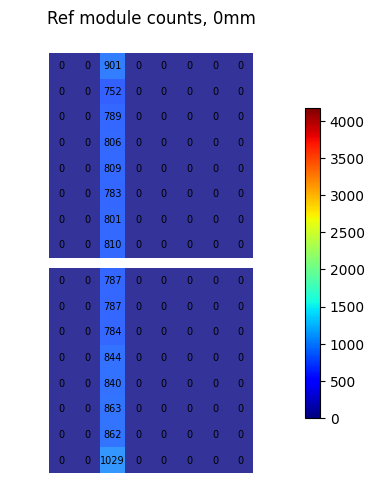

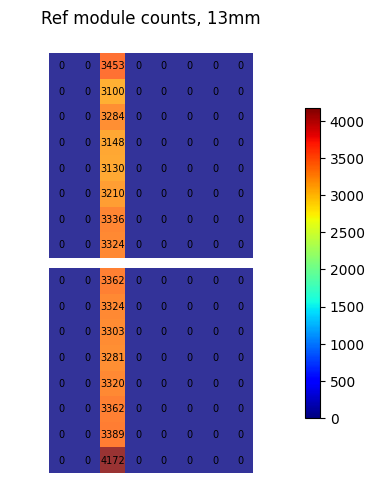

In [53]:
event_counts_list = []
max_vals = []

for dat in filtered_doi_data:
    ids = np.asarray(dat[:, 1] % 128, dtype=np.int32)
    event_counts = np.zeros((128), dtype=np.int32)
    np.add.at(event_counts, ids, 1)
    event_counts_list.append(event_counts)
    max_vals.append(np.max(event_counts))

max_vals = np.asarray(max_vals)
max_val = np.max(max_vals)
def get_color(val):
    return plt.cm.jet(val / max_val)

figs = []
for i in range(len(event_counts_list)):
    fig, ax = plt.subplots(figsize=(4, 6))
    for n in range(0, 128):
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        color_val = plt.cm.jet(event_counts_list[i][n] / max_val)
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0, facecolor=color_val, alpha=0.8)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, event_counts_list[i][n], fontsize=7, ha='center', va='center')

    plt.tick_params(axis='both', which='both', bottom=False, top=False,
                    left=False, right=False, labelbottom=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.ylim(0, 16)
    plt.xlim(0, 8)
    plt.axis('equal')
    
    # Add colorbar
    sm = ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=0, vmax=max_val))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.05, pad=0.04)
    
    plt.title(f'Ref module counts, {names[i]}')
    plt.show()
    figs.append(fig)

IndexError: list index out of range

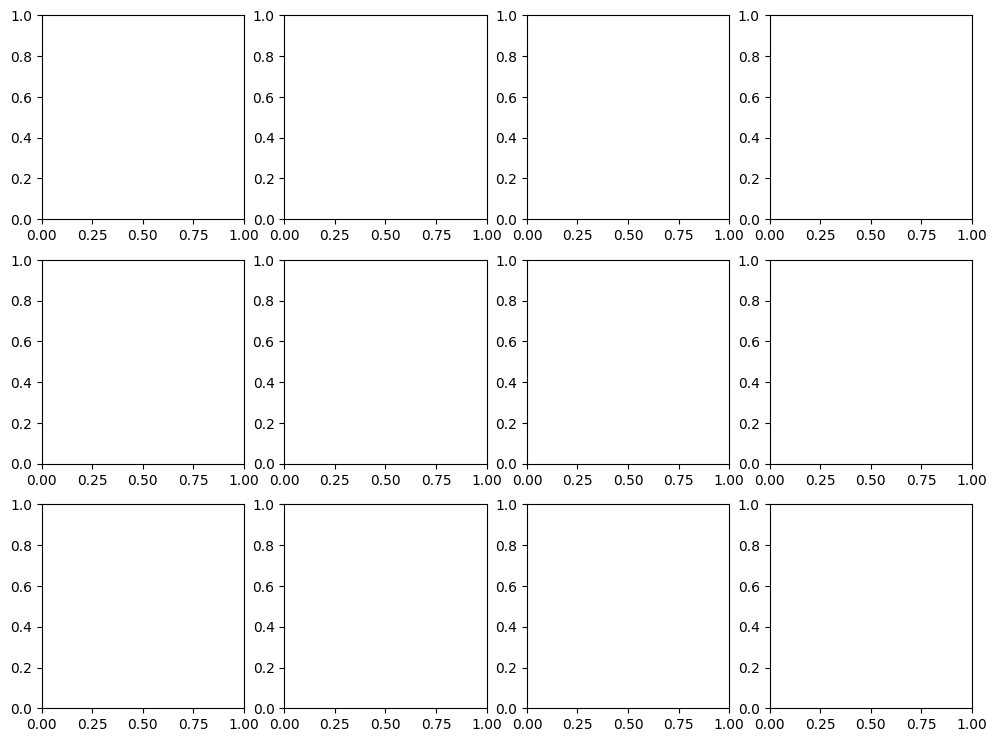

In [160]:
dataindex = 2
fig, subplots = plt.subplots(3, 4, figsize=(12, 9))
subplots = subplots.flatten()
for i in range(12):
    randomid6 = random.randint(768, 895) 
    energies6 = filtered_doi_data[dataindex][:, 0][filtered_doi_data[dataindex][:, 1] == randomid6]
    energies6a = filtered_doi_data[0][:, 0][filtered_doi_data[0][:, 1] == randomid6]
    hist, bins = subplots[i].hist(energies6, bins=60, range=(0, 40), color='purple', histtype='step')[0:2]
    bincenters = (bins[:-1] + bins[1:]) / 2
    fit_p = findPhotopeak(hist, bincenters)
    subplots[i].plot(np.linspace(0, 40, 100), gaussian(np.linspace(0, 40, 100), *fit_p), color='purple', linestyle='--', label=f'mu={fit_p[1]:.2f}')
    hist, bins = subplots[i].hist(energies6a, bins=60, range=(0, 40), color='blue', histtype='step')[0:2]
    bincenters = (bins[:-1] + bins[1:]) / 2
    fit_p = findPhotopeak(hist, bincenters)
    subplots[i].plot(np.linspace(0, 40, 100), gaussian(np.linspace(0, 40, 100), *fit_p), color='blue', linestyle='--', label=f'mu={fit_p[1]:.2f}')
    subplots[i].set_title(f'ID6 {randomid6}')
    subplots[i].set_xlabel('Energy (DAQ units)')
    subplots[i].set_ylabel('Counts')
    subplots[i].legend()
plt.tight_layout()
plt.show()
        

In [359]:
shifts3 = []
initpeaks3 = []
shifts0 =[]
initpeaks0 = []

[72, 69, 67, 74, 65, 64, 85, 80]


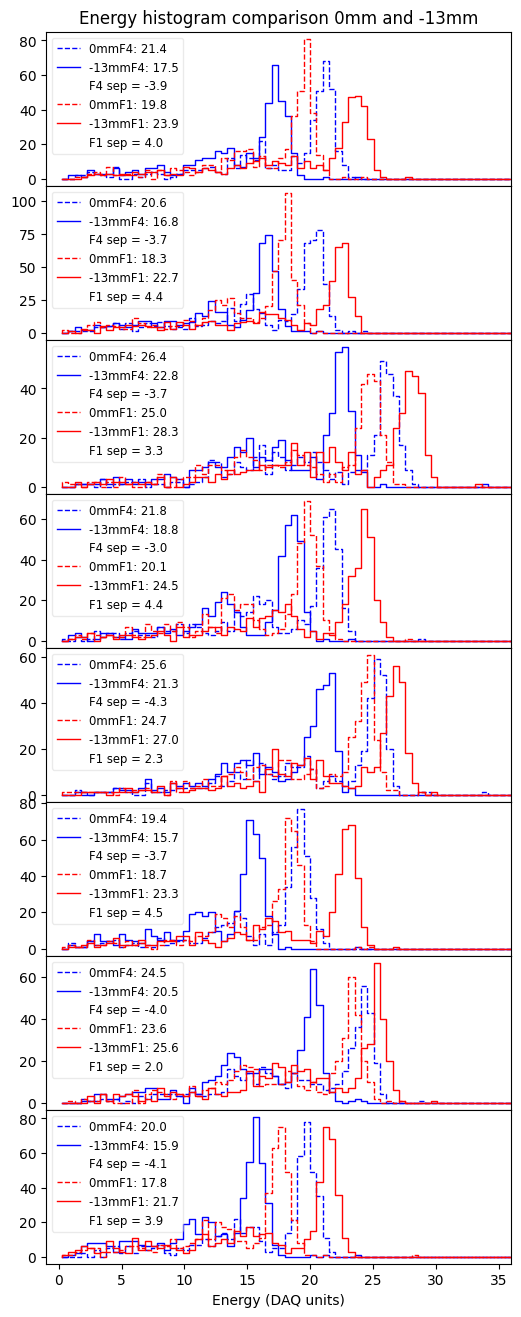

In [360]:
print(crystal_indices)
doi_index1, doi_index2 = 0, 5
bins = np.linspace(0, 40, 80)
fig, subplots = plt.subplots(8, 1, figsize =(6, 16))
for i in range(len(crystal_indices)):
    crystal_index = crystal_indices[i]
    bincenters = (bins[:-1] + bins[1:]) / 2
    channel1 = filtered_doi_data[doi_index1][filtered_doi_data[doi_index1][:, 5] == crystal_index]
    channel2 = filtered_doi_data[doi_index2][filtered_doi_data[doi_index2][:, 5] == crystal_index]
    channel1 = channel1[channel1[:, 3] == get_compliment(crystal_index) + 384]
    channel2 = channel2[channel2[:, 3] == get_compliment(crystal_index) + 384]
    hist31, bins31 = np.histogram(channel1[:, 2], bins=bins)
    hist01, bins01 = np.histogram(channel1[:, 4], bins=bins)
    hist32, bins32 = np.histogram(channel2[:, 2], bins=bins)
    hist02, bins02 = np.histogram(channel2[:, 4], bins=bins)
    fit_p31 = findPhotopeak(hist31, bincenters)
    fit_p01 = findPhotopeak(hist01, bincenters)
    fit_p32 = findPhotopeak(hist32, bincenters)
    fit_p02 = findPhotopeak(hist02, bincenters)
    shifts3.append(fit_p32[1] - fit_p31[1])
    initpeaks3.append(fit_p31[1])
    shifts0.append(fit_p02[1] - fit_p01[1])
    initpeaks0.append(fit_p01[1])
    subplots[i].step(bincenters, hist31, color = 'blue', label = f'0mmF4: {fit_p31[1]:.1f}', linewidth = 1, linestyle = '--')
    subplots[i].step(bincenters, hist32, color = 'blue', label = f'-13mmF4: {fit_p32[1]:.1f}', linewidth = 1)
    subplots[i].plot([0, 0], [0, 0], alpha = 0, label = f'F4 sep = {fit_p32[1] - fit_p31[1]:.1f}')
    subplots[i].step(bincenters, hist01, color = 'red', label = f'0mmF1: {fit_p01[1]:.1f}', linewidth = 1, linestyle = '--')
    subplots[i].step(bincenters, hist02, color = 'red', label = f'-13mmF1: {fit_p02[1]:.1f}', linewidth = 1)
    subplots[i].plot([0, 0], [0, 0], alpha = 0, label = f'F1 sep = {fit_p02[1] - fit_p01[1]:.1f}')
    #plt.plot(np.linspace(0, 40, 100), gaussian(np.linspace(0, 40, 100), *fit_p3), color='blue', label=f'mu={fit_p3[1]:.2f}')
    #plt.plot(np.linspace(0, 40, 100), gaussian(np.linspace(0, 40, 100), *fit_p0), color='red', label=f'mu={fit_p0[1]:.2f}')
    subplots[i].legend(fontsize = 'small', loc = 'upper left', framealpha = 0.4)
    subplots[i].set_xlim(-1, 36)
    #print(np.sum(mask))
plt.subplots_adjust(hspace=0, wspace=0)
for ax in subplots[0:7]:
    ax.set_xticklabels([])
subplots[-1].set_xlabel('Energy (DAQ units)')
subplots[0].set_title('Energy histogram comparison 0mm and -13mm')
plt.show()

NameError: name 'initpeaks0' is not defined

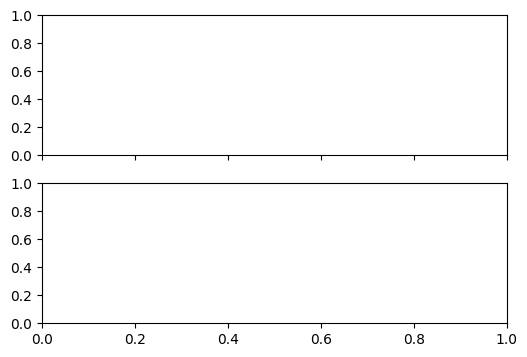

In [4]:
fig, subplots = plt.subplots(2, 1, figsize =(6, 4), sharex = True)
subplots = subplots.flatten()
subplots[0].scatter(initpeaks0, shifts0, color = 'red', s = 10)
subplots[1].scatter(initpeaks3, shifts3, color = 'blue', s = 10)
subplots[0].set_xlabel('Initial peak (DAQ units)')
fig.supylabel('Shift (DAQ units)')
fig.supxlabel('Initial peak (DAQ units)')
plt.subplots_adjust(hspace=0, wspace=0)

In [74]:
# Photopeak cuts, normalization and NCD
cut_range = 2.5
pedestal = 0
bins = 100
bins = np.linspace(0, 40, bins)
bincenters = (bins[:-1] + bins[1:]) / 2
ncd_data = [] # list of lists corresponding to datasets, each list contains NCD values for each crystal in index order

# Compute and store photopeak fits for center data by crystal
photopeaks = {}  # key: i, value: (fit_p3, fit_p0)

# For all doi_data, apply cuts and normalization using the fits from data
for doi in filtered_doi_data:
    curr_ncd_data = []
    #for i in crystal_indices:
    for i in range(64, 128):
        # Get relevant crystal data, channel is data for the channel pair on one crystal
        channel = doi[doi[:, 5] == i]
        channel = channel[channel[:, 3] == get_compliment(i) + 384]
        
        # Photopeak fits for cutting
        hist3, bins3 = np.histogram(channel[:, 2], bins=bins, range=(0, 40))
        fit_p3 = findPhotopeak(hist3, bincenters)
        hist0, bins0 = np.histogram(channel[:, 4], bins=bins, range=(0, 40))
        fit_p0 = findPhotopeak(hist0, bincenters)
        bounds3 = [fit_p3[1] - cut_range * fit_p3[2], fit_p3[1] + cut_range * fit_p3[2]]
        bounds0 = [fit_p0[1] - cut_range * fit_p0[2], fit_p0[1] + cut_range * fit_p0[2]]
        mask = (channel[:, 2] > bounds3[0]) & (channel[:, 2] < bounds3[1]) & (channel[:, 4] > bounds0[0]) & (channel[:, 4] < bounds0[1])
        channel = channel[mask]
        # If fit doesn't exist in photopeaks, store:
        if i not in photopeaks:
            photopeaks[i] = (fit_p3, fit_p0)

        # Normalization
        fit_p3, fit_p0 = photopeaks[i]
        channel[:, 2] = (channel[:, 2] - pedestal) / (fit_p3[1] - pedestal)
        channel[:, 4] = (channel[:, 4] - pedestal) / (fit_p0[1] - pedestal)

        # Normalized Charge Difference (NCD)
        ncd = (channel[:, 4] - channel[:, 2]) / (channel[:, 4] + channel[:, 2])
        # Just charge difference
        #ncd = channel[:, 4] - channel[:, 2]
        curr_ncd_data.append(ncd)
    ncd_data.append(curr_ncd_data)

print(len(ncd_data), len(ncd_data[0]), len(photopeaks))

Photopeak fit failed <built-in function id>
Photopeak fit failed <built-in function id>
Photopeak fit failed <built-in function id>
2 64 64


2


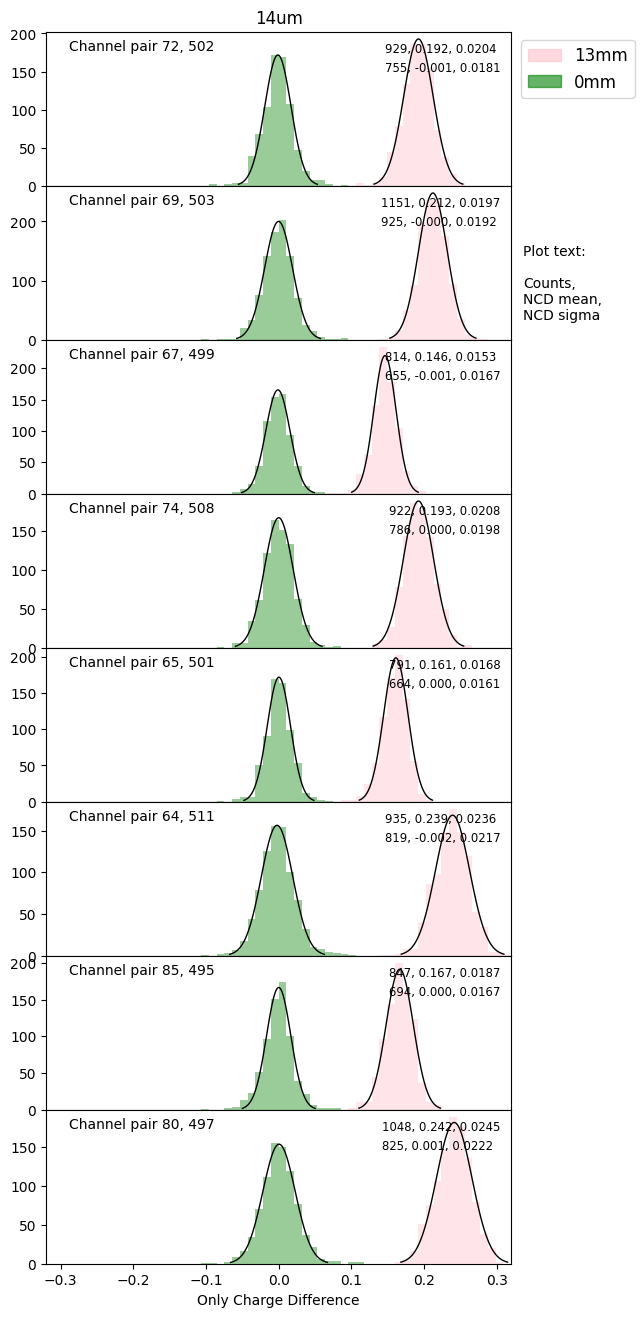

In [23]:
# Custom NCD plotting
fig, subplots = plt.subplots(8, 1, figsize = (6, 16))
histrange = (-0.32, 0.32)
subplots = subplots.flatten()
#colors = ['green', 'red', 'orange', 'yellow', 'blue', 'purple', 'pink']
colors = ['green', 'pink']
print(len(names))
labels = [Patch(color=colors[_], label=names[_], alpha=0.4) for _ in range(len(names))]
popts = [[] for _ in range(8)]
plot_labels = [[] for _ in range(8)]

for i in range(len(crystal_indices)):
    for j in range(len(filtered_doi_data)):
        hist, bins = subplots[i].hist(ncd_data[j][i], bins=60, range=histrange, color=colors[j], alpha = 0.4)[0:2]
        bincenters = (bins[:-1] + bins[1:]) / 2
        popt, pcov = curve_fit(gaussian, bincenters, hist, p0 = [np.max(hist), bincenters[np.argmax(hist)], 0.1])
        plotting_bounds = np.linspace(popt[1] - 3*popt[2], popt[1] + 3*popt[2], 100)
        subplots[i].plot(plotting_bounds, gaussian(plotting_bounds, *popt), color='black', linewidth = 1)
        plot_labels[i].append(f'{len(ncd_data[j][i])}, {popt[1]:.3f}, {np.abs(popt[2]):.4f}')
        popts[i].append(popt)
    subplots[i].text(0.05, 0.95, f'Channel pair {crystal_indices[i]}, {get_compliment(crystal_indices[i]) + 384}', 
                     fontsize=10, ha='left', va='top', transform=subplots[i].transAxes)
for i in range(len(plot_labels)):
    legend_handles = []
    for j in range(len(plot_labels[i])):
        legend_handles.append(Patch(color=colors[j], alpha=0, label=plot_labels[i][j]))
    legend_handles.insert(3, legend_handles.pop(0))
    subplots[i].legend(handles=legend_handles, loc='upper right', fontsize='small', framealpha=0)
for ax in subplots:
    ax.set_xlim(*histrange)
for ax in subplots[:7]:
    ax.set_xticklabels([])
plt.subplots_adjust(hspace=0, wspace=0.1)
subplots[-1].set_xlabel('Only Charge Difference')
subplots[0].set_title('14um')

labels = [Patch(color=colors[j], label=names[j], alpha=0.6) for j in range(len(names))]
labels.insert(3, labels.pop(0))
fig.legend(handles=labels, bbox_to_anchor=(1.12, 0.88), fontsize='large')
fig.text(0.92, 0.70, 'Plot text:\n\nCounts,\nNCD mean,\nNCD sigma')
plt.show()

plt.show()

/tmp/ipykernel_43660/4280823113.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(linear, distances, subplot_data[i])


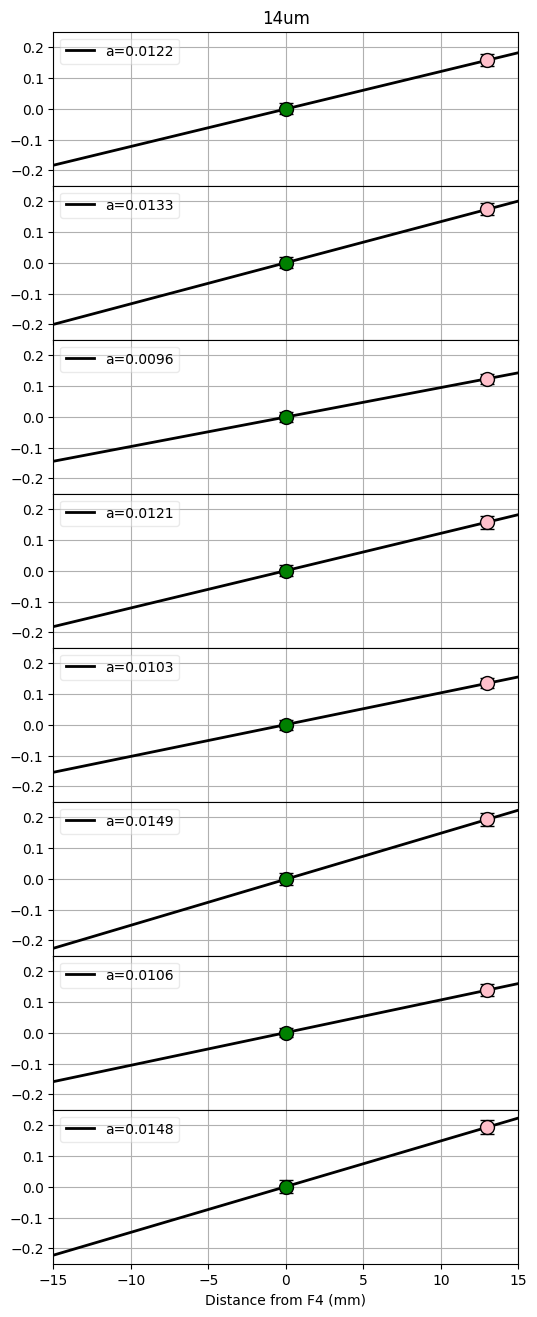

In [20]:
# Custom line plots

def linear(x, m, b):
    return m*x + b

fig, subplots = plt.subplots(8, 1, figsize=(6, 16))
subplots = subplots.flatten()
subplot_data = [[] for _ in range(8)]
slopes = []

for i in range(len(crystal_indices)):
    for j in range(len(filtered_doi_data)):
        gauss_popt = popts[i]
        subplots[i].errorbar(distances[j], gauss_popt[j][1], 2.355/2*np.abs(gauss_popt[j][2]), 
                            markerfacecolor = colors[j], markeredgecolor = 'black', fmt = 'o', 
                            markersize = 10, elinewidth = 2, capsize = 5, ecolor = 'black')
        subplot_data[i].append(gauss_popt[j][1])
    #print(subplot_data[i])
for i in range(len(subplot_data)):
    popt, pcov = curve_fit(linear, distances, subplot_data[i])
    plotting_bounds = np.linspace(-15, 15, 2)
    subplots[i].plot(plotting_bounds, linear(plotting_bounds, *popt), color = 'black', linewidth = 2, label = f'a={popt[0]:.4f}')
    subplots[i].legend(loc = 'upper left', framealpha = 0.4)
    slopes.append(popt[0])
# Ensure all subplots share the x-axis and the same xticks, and remove space between plots
for ax in subplots:
    ax.grid()
    ax.set_xlim(-15, 15)
    ax.set_ylim(-0.25, 0.25)
for ax in subplots[0:7]:
    ax.set_xticklabels([])
plt.subplots_adjust(hspace=0, wspace=0) # Spacing

subplots[-1].set_xlabel('Distance from F4 (mm)')
subplots[0].set_title('14um')

plt.show()


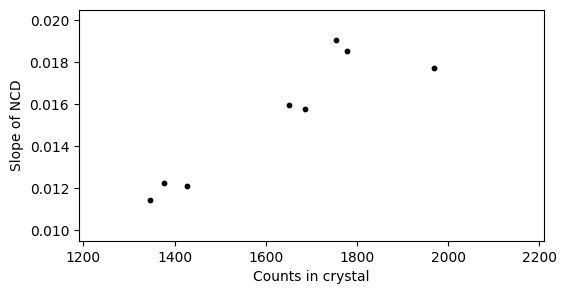

In [285]:
counts = []
for i in range(len(crystal_indices)):
    count = 0
    for j in range(len(filtered_doi_data)):
        count += len(ncd_data[j][i])
    counts.append(count)
plt.figure(figsize=(6, 3))
plt.scatter(counts, slopes, color = 'black', s = 10)
plt.xlim(1190, 2210)
plt.ylim(0.0095, 0.0205)
plt.xlabel('Counts in crystal')
plt.ylabel('Slope of NCD')
plt.show()


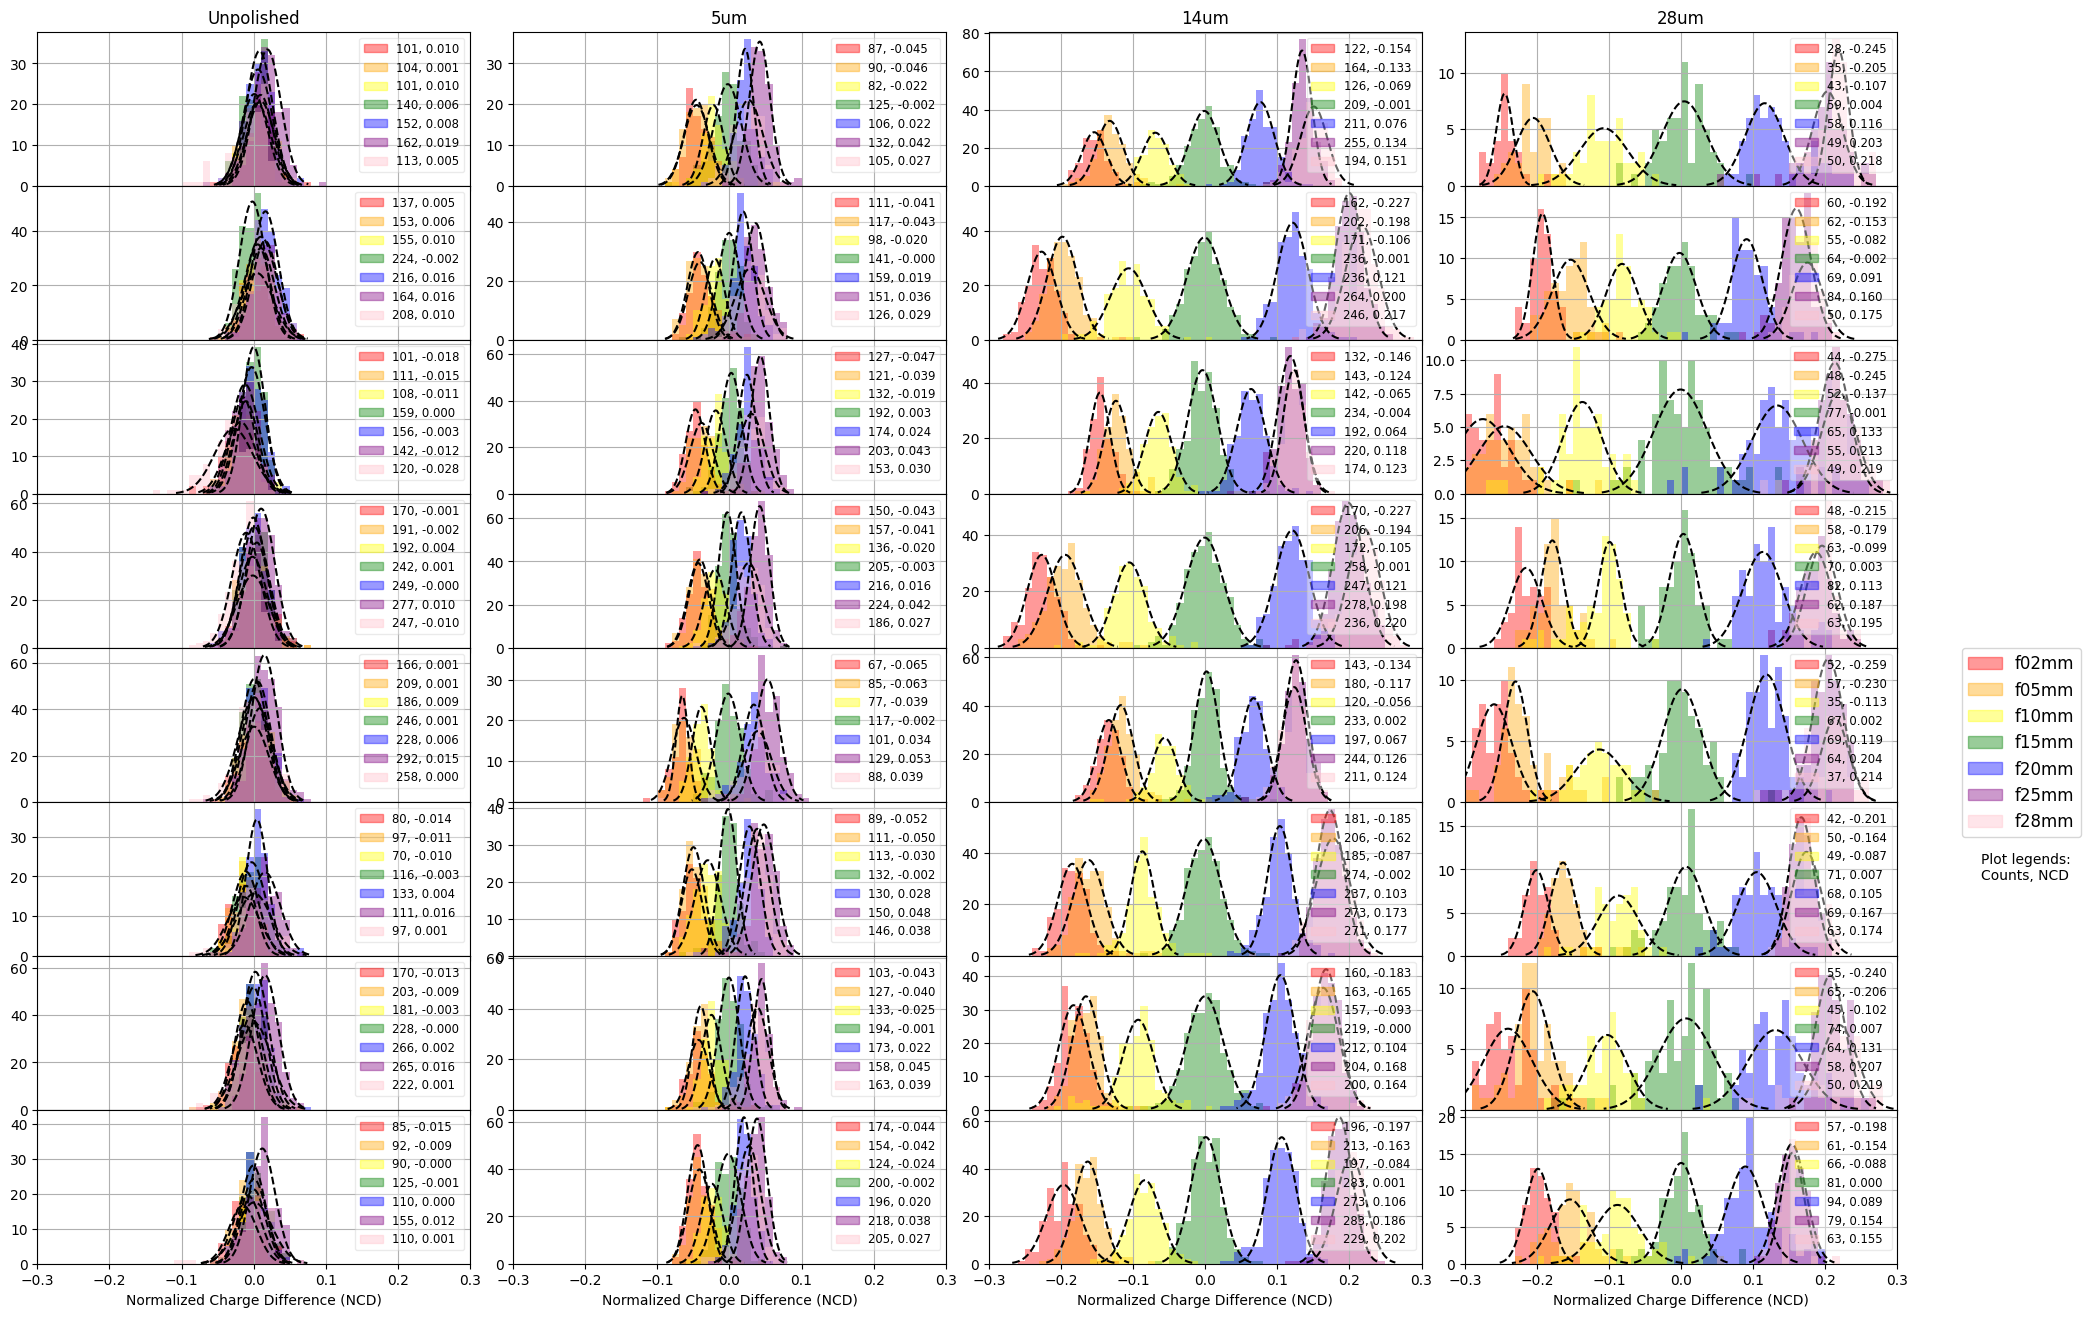

In [ ]:
# Per crystal NCD, histogram form
fig, subplots = plt.subplots(8, 4, figsize=(24, 16))
subplots = subplots.flatten()

labels = [Patch(color=colors[j], label=names[j], alpha=0.4) for j in range(len(names))]
labels.insert(3, labels.pop(0))
popts = [[] for _ in range(32)]
plot_labels = [[] for _ in range(32)]

for i in range(len(indices_list)):
    for j in range(len(doi_data)):

        curr_unpolished_index = 0
        for k in range(len(indices_list[i])):
            ncds = ncd_data[j][indices_list[i][k] - 64]
            if i == 0 and curr_unpolished_index < 8:
                hist, bins = subplots[curr_unpolished_index*4].hist(ncds, bins=60, range=(-0.30, 0.30), color=colors[j], alpha=0.4)[0:2]
                bincenters = (bins[:-1] + bins[1:]) / 2
                popbincenters = (bins[:-1] + bins[1:]) / 2
                popt, pcov = curve_fit(gaussian, bincenters, hist)
                plotting_bounds = np.linspace(popt[1] - 3*popt[2], popt[1] + 3*popt[2], 100)
                subplots[curr_unpolished_index*4].plot(plotting_bounds, gaussian(plotting_bounds, *popt), color='black', linestyle='--')

                plot_labels[curr_unpolished_index*4].append(f'{len(ncds)}, {popt[1]:.3f}')
                popts[curr_unpolished_index*4].append(popt)
                curr_unpolished_index += 1
            elif i != 0:
                hist, bins = subplots[k*4+i].hist(ncds, bins=60, range=(-0.30, 0.30), color=colors[j], alpha=0.4, label=f'{len(ncds)} events')[0:2]
                bincenters = (bins[:-1] + bins[1:]) / 2
                popt, pcov = curve_fit(gaussian, bincenters, hist)
                plotting_bounds = np.linspace(popt[1] - 3*popt[2], popt[1] + 3*popt[2], 100)
                subplots[k*4+i].plot(plotting_bounds, gaussian(plotting_bounds, *popt), color='black', linestyle='--')
                plot_labels[k*4+i].append(f'{len(ncds)}, {popt[1]:.3f}')
                popts[k*4+i].append(popt)
for i in range(len(plot_labels)):
    legend_handles = []
    for j in range(len(plot_labels[i])):
        legend_handles.append(Patch(color=colors[j], alpha=0.4, label=plot_labels[i][j]))
    legend_handles.insert(3, legend_handles.pop(0))
    subplots[i].legend(handles=legend_handles, loc='upper right', fontsize='small', framealpha=0.4)

# Ensure all subplots share the x-axis and the same xticks, and remove space between plots
for ax in subplots:
    ax.grid()
    ax.set_xlim(-0.30, 0.30)
for ax in subplots[0:28]:
    ax.set_xticklabels([])

plt.subplots_adjust(hspace=0, wspace=0.1) # Spacing

subplots[-4].set_xlabel('Normalized Charge Difference (NCD)')
subplots[-3].set_xlabel('Normalized Charge Difference (NCD)')
subplots[-2].set_xlabel('Normalized Charge Difference (NCD)')
subplots[-1].set_xlabel('Normalized Charge Difference (NCD)')
subplots[0].set_title('Unpolished')
subplots[1].set_title('5um')
subplots[2].set_title('14um')
subplots[3].set_title('28um')


fig.legend(handles=labels, bbox_to_anchor=(0.98, 0.5), fontsize='large')
fig.text(0.935, 0.35, 'Plot legends:\nCounts, NCD')

plt.show()


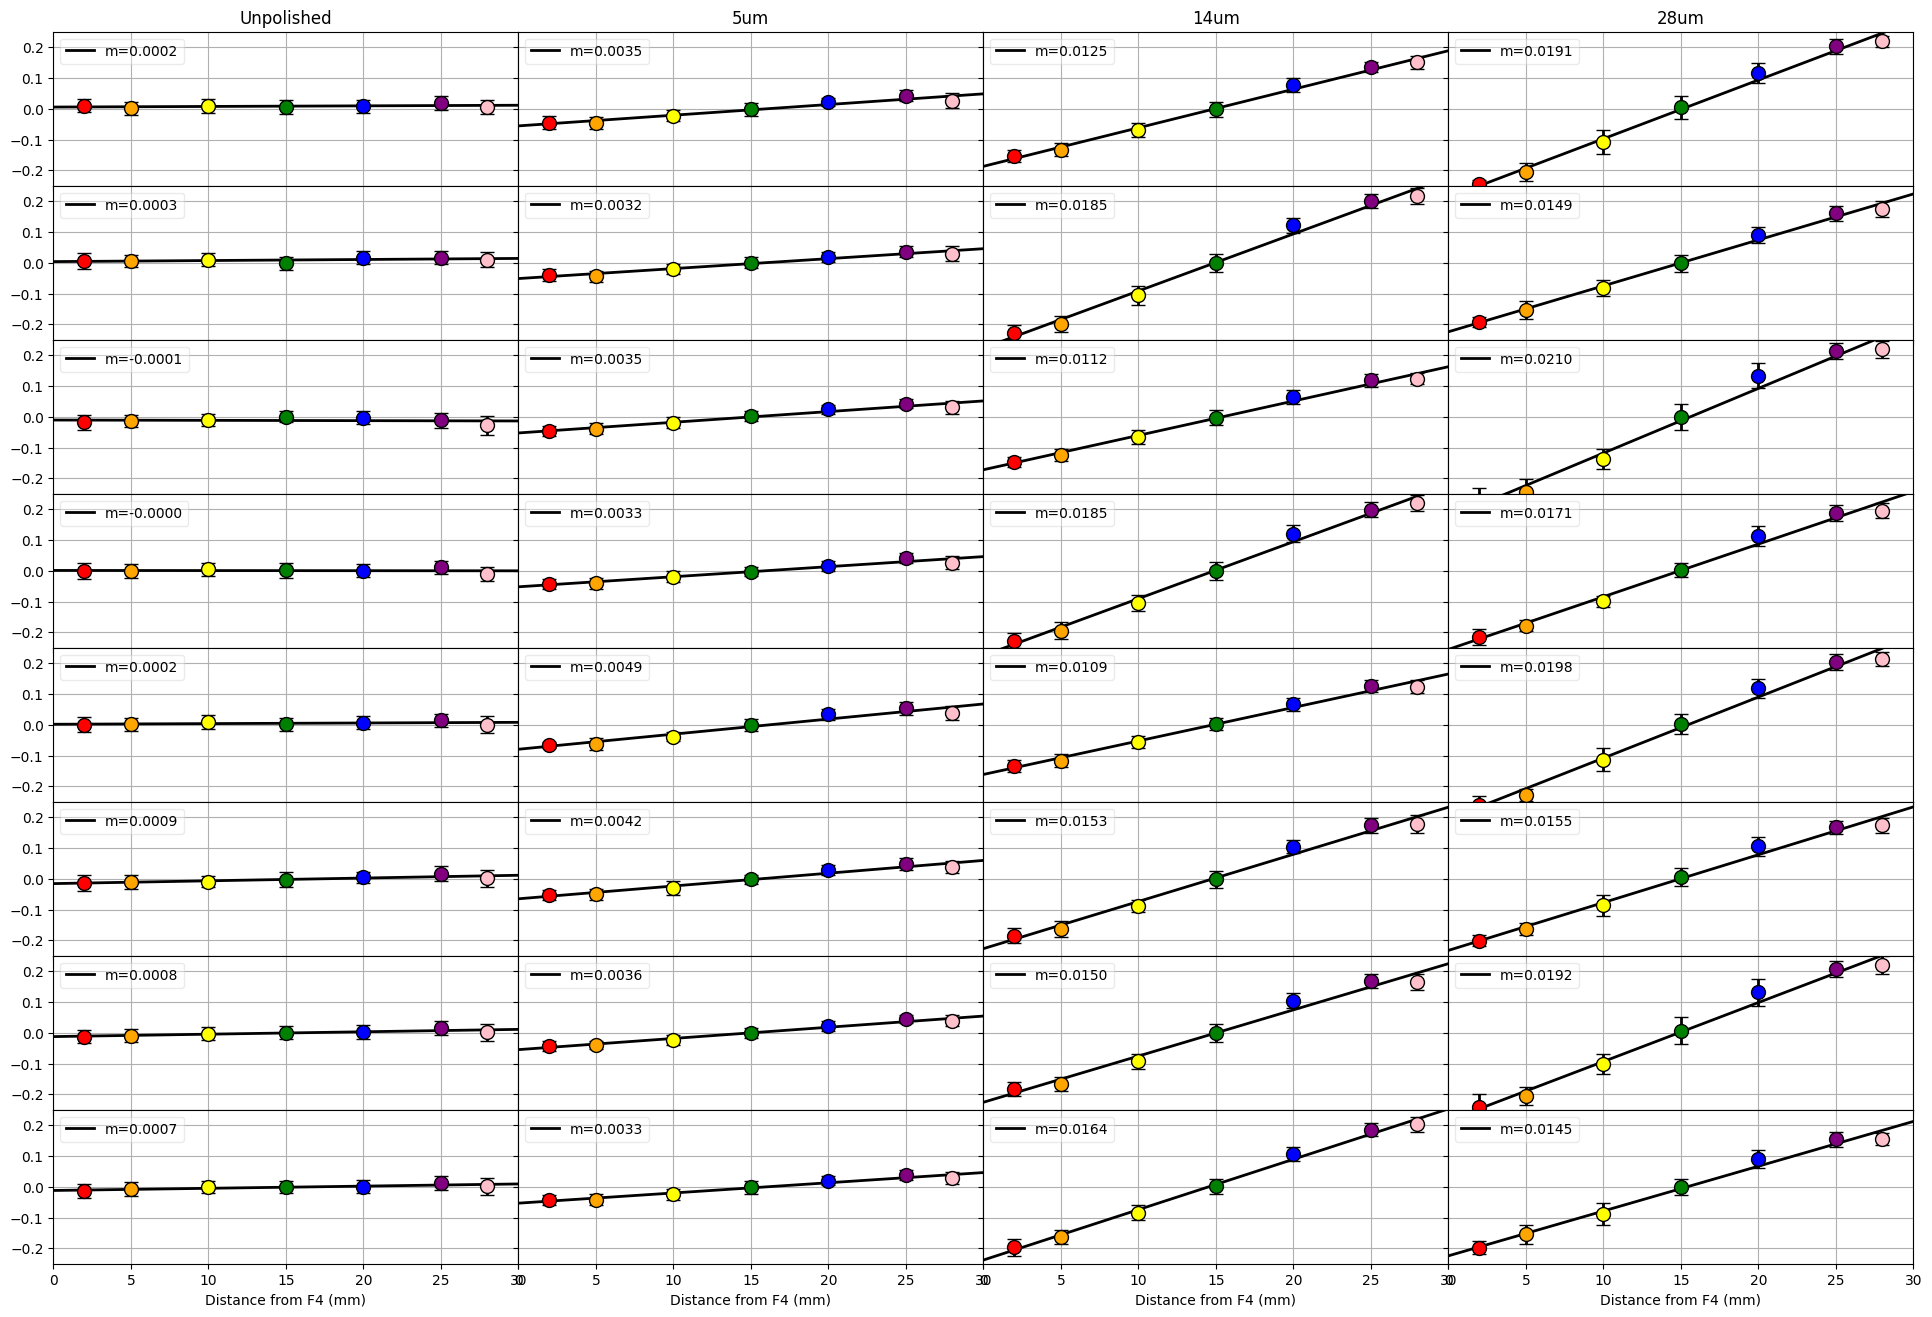

In [249]:
# Per crystal NCD, line plots

def linear(x, m, b):
    return m*x + b

fig, subplots = plt.subplots(8, 4, figsize=(24, 16))
subplots = subplots.flatten()
subplot_data = [[] for _ in range(32)]

for i in range(len(indices_list)):
    for j in range(len(doi_data)):

        curr_unpolished_index = 0
        for k in range(len(indices_list[i])):
            ncds = ncd_data[j][indices_list[i][k] - 64]
            if i == 0 and curr_unpolished_index < 8:
                gauss_popt = popts[curr_unpolished_index*4]
                subplots[curr_unpolished_index*4].errorbar(distances[j], gauss_popt[j][1], 2.355/2*np.abs(gauss_popt[j][2]), 
                            markerfacecolor = colors[j], markeredgecolor = 'black', fmt = 'o', 
                            markersize = 10, elinewidth = 2, capsize = 5, ecolor = 'black')
                subplot_data[curr_unpolished_index*4].append(gauss_popt[j][1])
                curr_unpolished_index += 1
            elif i != 0:
                gauss_popt = popts[k*4+i]
                subplots[k*4+i].errorbar(distances[j], gauss_popt[j][1], 2.355/2*np.abs(gauss_popt[j][2]), 
                            markerfacecolor = colors[j], markeredgecolor = 'black', fmt = 'o', 
                            markersize = 10, elinewidth = 2, capsize = 5, ecolor = 'black')
                subplot_data[k*4+i].append(gauss_popt[j][1])

for i in range(len(subplot_data)):
    popt, pcov = curve_fit(linear, distances, subplot_data[i])
    plotting_bounds = np.linspace(0, 30, 2)
    subplots[i].plot(plotting_bounds, linear(plotting_bounds, *popt), color = 'black', linewidth = 2, label = f'm={popt[0]:.4f}')
    subplots[i].legend(loc = 'upper left', framealpha = 0.4)

# Ensure all subplots share the x-axis and the same xticks, and remove space between plots
for ax in subplots:
    ax.grid()
    ax.set_xlim(0, 30)
    ax.set_ylim(-0.25, 0.25)
for ax in subplots[0:28]:
    ax.set_xticklabels([])
for ax in [a for i, a in enumerate(subplots) if i % 4 != 0]:
    ax.set_yticklabels([])
plt.subplots_adjust(hspace=0, wspace=0) # Spacing

subplots[-4].set_xlabel('Distance from F4 (mm)')
subplots[-3].set_xlabel('Distance from F4 (mm)')
subplots[-2].set_xlabel('Distance from F4 (mm)')
subplots[-1].set_xlabel('Distance from F4 (mm)')
subplots[0].set_title('Unpolished')
subplots[1].set_title('5um')
subplots[2].set_title('14um')
subplots[3].set_title('28um')


plt.show()


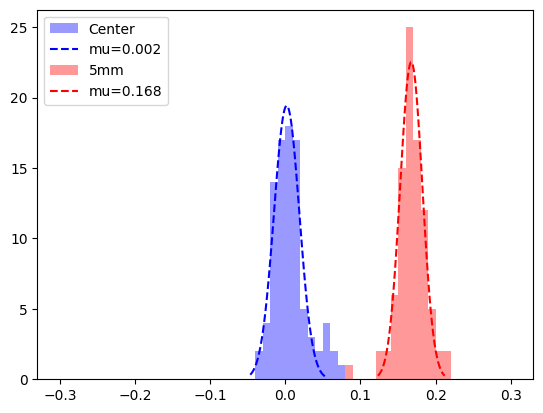

In [40]:
# Plotting singular NCD
index = 82
hist, bins = plt.hist(ncd_data[0][index - 64], bins = 60, range = (-0.30, 0.30), color = 'blue', alpha = 0.4, label = 'Center')[0:2]
bincenters = (bins[:-1] + bins[1:]) / 2
popt, pcov = curve_fit(gaussian, bincenters, hist)
plotting_bounds = np.linspace(popt[1] - 3*popt[2], popt[1] + 3*popt[2], 100)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'blue', linestyle = '--', label = f'mu={popt[1]:.3f}')
plt.legend(loc = 'upper left')
hist, bins = plt.hist(ncd_data[1][index - 64], bins = 60, range = (-0.30, 0.30), color = 'red', alpha = 0.4, label = '5mm')[0:2]
popt, pcov = curve_fit(gaussian, bincenters, hist)
plotting_bounds = np.linspace(popt[1] - 3*popt[2], popt[1] + 3*popt[2], 100)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'red', linestyle = '--', label = f'mu={popt[1]:.3f}')
plt.legend(loc = 'upper left')
plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


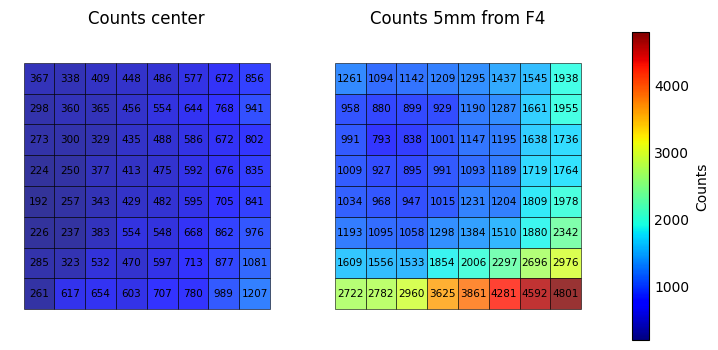

In [85]:
# Population heatmaps
reldata = doi_data[0]
counts0 = np.zeros((8, 8))
counts3 = np.zeros((8, 8))


for row in range(8, 16):
    list_indices = dict(sorted(
        ((k, v) for k, v in indices.items() if v[0] == row),
        key=lambda item: item[1][1]
    ))
    list_indices = list(list_indices.keys())
    for i in range(len(list_indices)):
        photopeak3 = photopeaks[list_indices[i]][0]
        photopeak0 = photopeaks[list_indices[i]][1]
        #print(photopeak3, photopeak0, list_indices[i], get_compliment(list_indices[i]))
        channel = reldata[(reldata[:, 5] == list_indices[i]) & (reldata[:, 3] == get_compliment(list_indices[i]) + 384)]
        mask = (channel[:, 2] > photopeak3[1] - 3*photopeak3[2]) & (channel[:, 2] < photopeak3[1] + 3*photopeak3[2]) & (channel[:, 4] > photopeak0[1] - 3*photopeak0[2]) & (channel[:, 4] < photopeak0[1] + 3*photopeak0[2])
        counts0[row-8, i] = len(channel[mask])
        counts3[row-8, i] = len(channel)
        #break
    #break
        
max_counts = max(np.max(counts0), np.max(counts3))
min_counts = min(np.min(counts0), np.min(counts3))

def get_color(val):
    return plt.cm.jet((val - min_counts) / (max_counts - min_counts))

fig, axes = plt.subplots(1, 3, figsize=(8.25, 4), gridspec_kw={'width_ratios': [4, 4, 0.25]})

ax = axes[0]
for n in range(64, 128):
    # Use the indices dictionary to get positions
    if n in indices:
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='black', facecolor=get_color(counts0[7-y, x]), alpha=0.8)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, str(int(counts0[7-y, x])), fontsize=7.5, ha='center', va='center')
    else:
        continue

ax.tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.axis('equal')
ax.set_ylim(-1, 9)
ax.set_xlim(-1, 9)
ax.set_title('Counts center')

ax = axes[1]
for n in range(64, 128):
    # Use the indices dictionary to get positions
    if n in indices:
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='black', facecolor=get_color(counts3[7-y, x]), alpha=0.8)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, str(int(counts3[7-y, x])), fontsize=7.5, ha='center', va='center')
    else:
        continue

ax.tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.axis('equal')
ax.set_ylim(-1, 9)
ax.set_xlim(-1, 9)
ax.set_title('Counts 5mm from F4')

# Make the third subplot the colorbar:
cax = axes[2]
cb = plt.colorbar(
    ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=min_counts, vmax=max_counts)),
    cax=cax,
    orientation='vertical'
)
cax.set_ylabel('Counts')
# Remove ticks and labels on colorbar axes for aesthetics, optional:
cax.tick_params(axis='both', which='both', length=0)
plt.show()

[3454. 2915. 2441. 1993. 1831. 1432. 1044.]


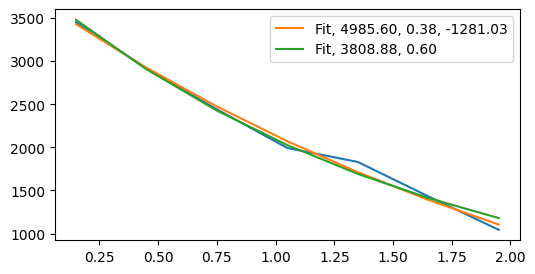

In [90]:
ys = np.sum(counts0[2:6], axis = 0)[::-1][:-1]
print(ys)
xs = np.array([0.15, 0.45, 0.75, 1.05, 1.35, 1.65, 1.95])[:len(ys)]
plt.figure(figsize=(6,3))
plt.plot(xs, ys)
def exp(x, a, b, c):
    return a * np.exp(-b * x) + c
def exp2(x, a, b):
    return a * np.exp(-b * x)
popt, pcov = curve_fit(exp, xs, ys, p0=(1000, 0.8, 100))
plt.plot(xs, exp(xs, *popt), label=f'Fit, {popt[0]:.2f}, {popt[1]:.2f}, {popt[2]:.2f}')
popt2, pcov2 = curve_fit(exp2, xs, ys, p0=(1000, 0.8))
plt.plot(xs, exp2(xs, *popt2), label=f'Fit, {popt2[0]:.2f}, {popt2[1]:.2f}')
plt.legend()
plt.show()

In [329]:
# Read in data for time difference analysis
doi_data = []
names = []
distances = []
for path in paths:
    df = pd.read_csv(path, sep = '\t', header=None)
    print(df.shape)
    reftime = df.iloc[:, 2] / 1000000000000
    t1 = df.iloc[:,12] - df.iloc[:,2]
    t2 = df.iloc[:,7] - df.iloc[:,2]
    print(reftime.dtype, t1.dtype, t2.dtype)
    df = df.iloc[:, [3, 4, 8, 9, 13, 14]]
    data = np.asarray(df, dtype = np.float32)
    data = np.column_stack((data, reftime, t1, t2))
    print(data)
    doi_data.append(data)
    names.append(path.split('/')[-1].split('.')[0])
    #distances.append(int(path.split('/')[-1].split('.')[0].split('mm')[0][1:]))

filter_data = True
module_ids = [k for k, v in indices.items() if v[1] in (1, 2, 3)]
filtered_doi_data = []
for dat in doi_data:
    if filter_data:
        filtered_data = dat[np.isin(dat[:, 1] - 768, module_ids)]
        filtered_doi_data.append(filtered_data)
        print(f"Original: {len(dat)}, Filtered: {len(filtered_data)}")
    else:
        filtered_doi_data.append(dat)

(73226, 15)
float64 int64 int64
[[ 2.74366531e+01  7.68000000e+02  1.73256073e+01 ...  6.59263986e+00
   7.89000000e+02 -1.07000000e+02]
 [ 1.09874344e+01  8.60000000e+02  1.59336395e+01 ...  6.64181531e+00
  -1.15900000e+03 -1.25000000e+02]
 [ 3.36954093e+00  7.91000000e+02  1.62691002e+01 ...  6.79872871e+00
  -1.55800000e+03 -5.86000000e+02]
 ...
 [ 3.10214462e+01  8.52000000e+02  2.25601120e+01 ...  5.40613875e+03
   5.21200000e+03  6.11600000e+03]
 [ 1.77285919e+01  8.18000000e+02  2.28126502e+00 ...  5.40618274e+03
   1.73400000e+03  2.41600000e+03]
 [ 1.84296951e+01  8.73000000e+02  3.78508806e+00 ...  5.40636715e+03
   6.30000000e+02  1.28200000e+03]]
(54389, 15)
float64 int64 int64
[[ 1.79685555e+01  8.39000000e+02  1.70599022e+01 ...  6.79183809e+00
  -1.28100000e+03 -2.02000000e+02]
 [ 2.91909256e+01  8.09000000e+02  1.30838661e+01 ...  6.79543168e+00
  -8.08000000e+02 -3.17000000e+02]
 [ 8.55053008e-01  8.27000000e+02  1.65292053e+01 ...  6.90373119e+00
  -4.97700000e+03 -5

In [330]:
# Photopeak cuts for time difference analysis
cut_range = 2.5

pcut_data = [] # list of lists corresponding to datasets, each list contains pcut values for each crystal in index order

# For all doi_data, apply cuts and normalization using the fits from data
for doi in filtered_doi_data:
    curr_pcut_data = []
    for i in range(64, 128):
        # Get relevant crystal data, channel is data for the channel pair on one crystal
        channel = doi[doi[:, 5] == i]
        channel = channel[channel[:, 3] == get_compliment(i) + 384]
        
        # Photopeak fits for cutting
        hist3, bins3 = np.histogram(channel[:, 2], bins=60, range=(0, 40))
        fit_p3 = findPhotopeak(hist3, bins3)
        hist0, bins0 = np.histogram(channel[:, 4], bins=60, range=(0, 40))
        fit_p0 = findPhotopeak(hist0, bins0)
        bounds3 = [fit_p3[1] - cut_range * fit_p3[2], fit_p3[1] + cut_range * fit_p3[2]]
        bounds0 = [fit_p0[1] - cut_range * fit_p0[2], fit_p0[1] + cut_range * fit_p0[2]]
        mask = (channel[:, 2] > bounds3[0]) & (channel[:, 2] < bounds3[1]) & (channel[:, 4] > bounds0[0]) & (channel[:, 4] < bounds0[1])
        channel = channel[mask]

        # Store pcut data
        curr_pcut_data.append(channel)

    pcut_data.append(curr_pcut_data)

print(len(pcut_data), len(pcut_data[0]))

2 64


Difference:  -561.2677612502914
Apparent CTRs:  468.4407614113284 512.8873694713724


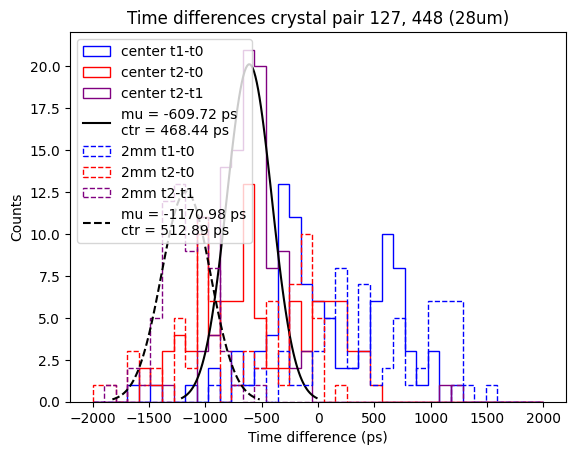

In [343]:
# For splitting into double peak
half1=np.asarray(list(range(0, 27)) + list(range(28, 33)) + list(range(64, 73)) + list(range(76, 97)) + [74, 102])
def asichalf10(events):
    return events[np.isin(events[:, 5] % 128, half1)]
def asichalf20(events):
    return events[~np.isin(events[:, 5] % 128, half1)]
def asichalf14(events):
    return events[np.isin(events[:, 3] % 128, half1)]
def asichalf24(events):
    return events[~np.isin(events[:, 3] % 128, half1)]

bins = np.linspace(-2000, 2000, 40)
bincenters = (bins[:-1] + bins[1:]) / 2
plottingspace = np.linspace(-2000, 2000, 100)

random_index = np.random.choice(rough28micron_indices) - 64 # Change this to look at different roughnesses
crystal0 = pcut_data[0][random_index]
plt.hist(crystal0[:, 7], bins=bins, range=(-2000, 2000), color='blue', histtype='step', label='center t1-t0')
plt.hist(crystal0[:, 8], bins=bins, range=(-2000, 2000), color='red', histtype='step', label='center t2-t0')
hist0 = plt.hist(crystal0[:, 8] - crystal0[:, 7], bins=bins, range=(-2000, 2000), color='purple', histtype='step', label='center t2-t1')[0]
popt0, pcov = curve_fit(gaussian, bincenters, hist0, p0 = [np.max(hist0), bincenters[np.argmax(hist0)], 100])
plotting_bounds = np.linspace(popt0[1] - 3*popt0[2], popt0[1] + 3*popt0[2], 100)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt0), color='black', linestyle='-', label='mu = {:.2f} ps\nctr = {:.2f} ps'.format(popt0[1], popt0[2] * 2.355))
crystal1 = pcut_data[1][random_index]
plt.hist(crystal1[:, 7], bins=bins, range=(-2000, 2000), color='blue', histtype='step', linestyle='--', label='2mm t1-t0')
plt.hist(crystal1[:, 8], bins=bins, range=(-2000, 2000), color='red', histtype='step', linestyle='--', label='2mm t2-t0')
hist1 = plt.hist(crystal1[:, 8] - crystal1[:, 7], bins=bins, range=(-2000, 2000), color='purple', histtype='step', linestyle='--', label='2mm t2-t1')[0]
popt1, pcov = curve_fit(gaussian, bincenters, hist1, p0 = [np.max(hist1), bincenters[np.argmax(hist1)], 100])
plotting_bounds = np.linspace(popt1[1] - 3*popt1[2], popt1[1] + 3*popt1[2], 100)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt1), color='black', linestyle='--', label='mu = {:.2f} ps\nctr = {:.2f} ps'.format(popt1[1], popt1[2] * 2.355))
plt.legend(loc = 'upper left')
plt.xlabel('Time difference (ps)')
plt.ylabel('Counts')
plt.title(f'Time differences crystal pair {random_index + 64}, {get_compliment(random_index + 64) + 384} (28um)')
print('Difference: ', popt1[1] - popt0[1])
print('Apparent CTRs: ', popt0[2] * 2.355, popt1[2] * 2.355)
plt.show()



(833, 9)


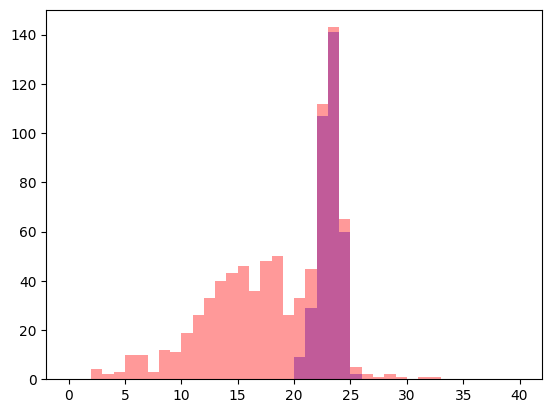

In [105]:
plt.hist(pcut_data[0][21][:,2], bins = 40, range = (0, 40), color='blue', alpha=0.4, label='t1-t0')
temp_data = filtered_doi_data[0][filtered_doi_data[0][:,5] == 21+64]
print(temp_data.shape)
plt.hist(temp_data[:,2], bins = 40, range = (0, 40), color='red', alpha=0.4, label='t1-t0')
plt.show()

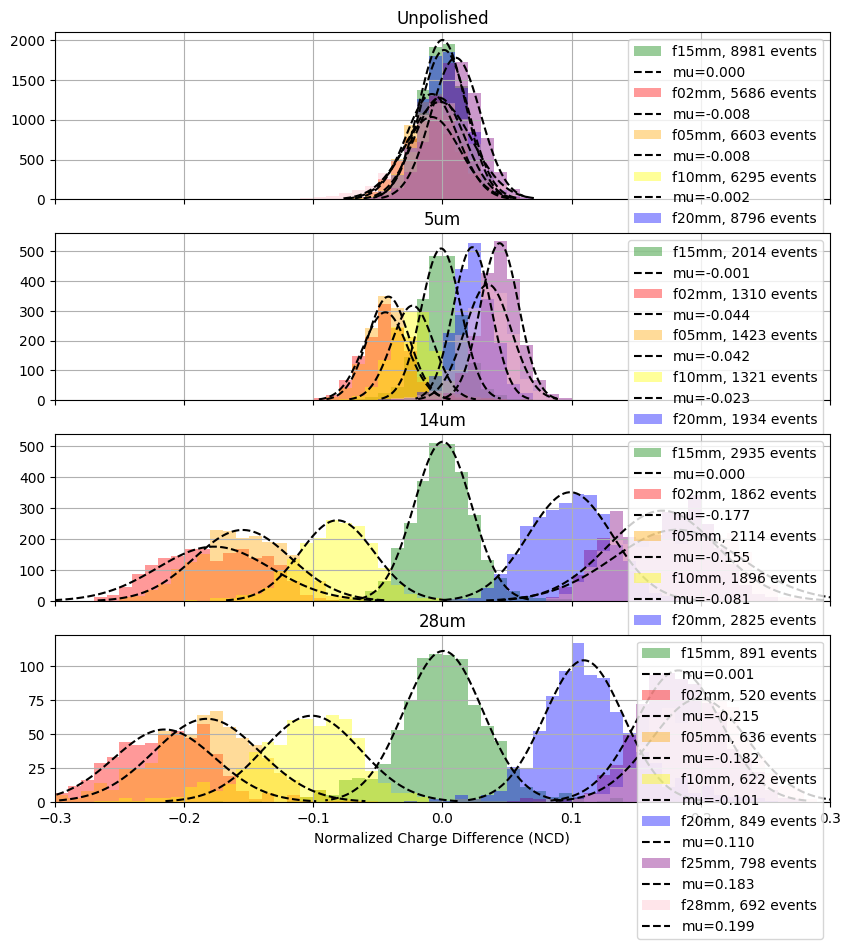

In [159]:
# Plotting NCD

# Hardcode indices
rough5micron_indices = [126, 102, 77, 79, 122, 91, 70, 72]
rough28micron_indices = [119, 118, 124, 115, 127, 117, 113, 111]
rough14micron_indices = [65, 64, 85, 80, 84, 82, 86, 81]
unpolished_indices = [x for x in range(64, 128) if x not in rough5micron_indices and x not in rough14micron_indices and x not in rough28micron_indices]
indices_list = [unpolished_indices, rough5micron_indices, rough14micron_indices, rough28micron_indices]

colors = ['green', 'red', 'orange', 'yellow', 'blue', 'purple', 'pink']
ax, subplots = plt.subplots(4, 1, figsize=(10, 10))
subplots = subplots.flatten()

for i in range(len(indices_list)):
    for j in range(len(doi_data)):
        ncds = []
        for index in indices_list[i]:
            ncds.append(ncd_data[j][index - 64])
        ncds = np.concatenate([np.asarray(arr) for arr in ncds])
        hist, bins = subplots[i].hist(ncds, bins=60, range=(-0.30, 0.30), color=colors[j], alpha=0.4, label=f'{names[j]}, {len(ncds)} events')[0:2]
        bincenters = (bins[:-1] + bins[1:]) / 2
        popt, pcov = curve_fit(gaussian, bincenters, hist)
        plotting_bounds = np.linspace(popt[1] - 3*popt[2], popt[1] + 3*popt[2], 100)
        subplots[i].plot(plotting_bounds, gaussian(plotting_bounds, *popt), color='black', linestyle='--', label=f'mu={popt[1]:.3f}')
        subplots[i].legend(loc='upper right')
   

# Ensure all subplots share the x-axis and the same xticks, and remove space between plots
for ax in subplots:
    ax.grid()
    ax.set_xlim(-0.30, 0.30)
for ax in subplots[0:3]:
    ax.set_xticklabels([])

plt.subplots_adjust(hspace=0.2)  # Remove vertical space between subplots

# Optionally, set one common x-label for all
subplots[-1].set_xlabel('Normalized Charge Difference (NCD)')
# Set a global title for the figure
subplots[0].set_title('Unpolished')
subplots[1].set_title('5um')
subplots[2].set_title('14um')
subplots[3].set_title('28um')

plt.show()
